<a href="https://colab.research.google.com/github/SURYA-ADS-eng/surya_cognifyz_DA/blob/main/surya_cognifyz_DA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
d=pd.read_csv("/content/Dataset .csv")
d.head()
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [ ]:
#LEVEL 1,TASK-1:

c=d['Cuisines'].dropna().str.split(', ')
ac= c.explode()

t3=ac.value_counts().head(3)
print("Top 3 cuisines:\n",t3)

percentage=(t3/len(d))*100
print("\nPercentage:\n",percentage)

Top 3 cuisines:
 Cuisines
North Indian    3960
Chinese         2735
Fast Food       1986
Name: count, dtype: int64

Percentage:
 Cuisines
North Indian    41.461627
Chinese         28.635745
Fast Food       20.793634
Name: count, dtype: float64


In [ ]:
#LEVEL 1,TASK-2:

cc= d['City'].value_counts()
print("City with highest restaurants:",cc.idxmax())

cr= d.groupby('City')['Aggregate rating'].mean()
print(cr.sort_values(ascending=False))

print("Highest rated city:", cr.idxmax())

City with highest restaurants: New Delhi
City
Inner City          4.900000
Quezon City         4.800000
Makati City         4.650000
Pasig City          4.633333
Mandaluyong City    4.625000
                      ...   
New Delhi           2.438845
Montville           2.400000
Mc Millan           2.400000
Noida               2.036204
Faridabad           1.866932
Name: Aggregate rating, Length: 141, dtype: float64
Highest rated city: Inner City


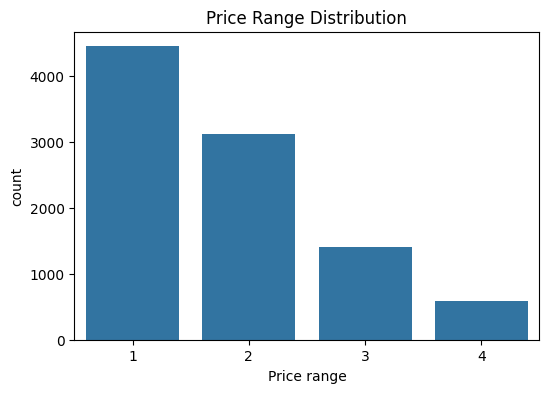

Price range
1    46.529159
2    32.593446
3    14.741912
4     6.135483
Name: proportion, dtype: float64


In [ ]:
#LEVEL 1,TASK-3:

import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6,4))
sns.countplot(x='Price range',data=d)

plt.title("Price Range Distribution")
plt.show()

pt=d['Price range'].value_counts(normalize=True)*100
print(pt)

In [ ]:
#LEVEL 1, TASK-4:

dp=d['Has Online delivery'].value_counts(normalize=True)*100
print("Online delivery %:\n",dp)

dr=d.groupby('Has Online delivery')['Aggregate rating'].mean()
print("\nAverage ratings comparison:\n",dr)

Online delivery %:
 Has Online delivery
No     74.337766
Yes    25.662234
Name: proportion, dtype: float64

Average ratings comparison:
 Has Online delivery
No     2.465296
Yes    3.248837
Name: Aggregate rating, dtype: float64


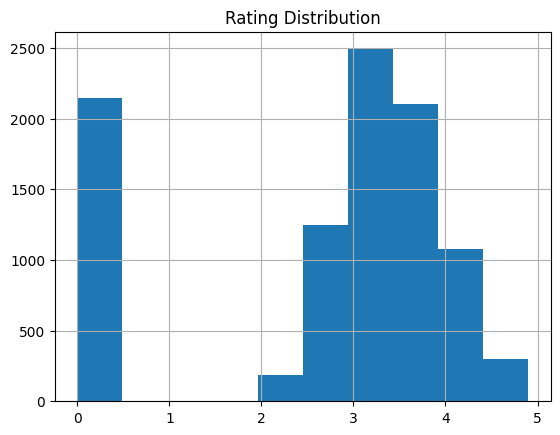

Most common rating: 0.0
Average votes: 156.909747670401


In [ ]:
#LEVEL 2, TASK-1:

d['Aggregate rating'].hist()
plt.title("Rating Distribution")
plt.show()

print("Most common rating:",d['Aggregate rating'].mode()[0])
print("Average votes:",d['Votes'].mean())

In [ ]:
#LEVEL 2, TASK-2:

cc=d['Cuisines'].value_counts().head(10)
print("Top combinations:\n",cc)

cr=d.groupby('Cuisines')['Aggregate rating'].mean().sort_values(ascending=False)
print("\nTop rated combinations:\n",cr.head(10))

Top combinations:
 Cuisines
North Indian                      936
North Indian, Chinese             511
Chinese                           354
Fast Food                         354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Name: count, dtype: int64

Top rated combinations:
 Cuisines
Burger, Bar Food, Steak            4.9
American, Burger, Grill            4.9
American, Caribbean, Seafood       4.9
American, Coffee and Tea           4.9
Mexican, American, Healthy Food    4.9
Italian, Bakery, Continental       4.9
BBQ, Breakfast, Southern           4.9
European, German                   4.9
Hawaiian, Seafood                  4.9
Sunda, Indonesian                  4.9
Name: Aggregate rating, dtype: float64


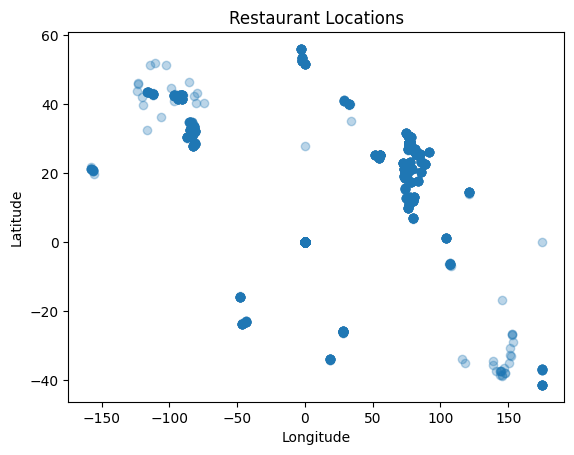

In [ ]:
#LEVEL 2, TASK-3:

plt.scatter(d['Longitude'],d['Latitude'],alpha=0.3)
plt.title("Restaurant Locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [ ]:
#LEVEL 2, TASK-4:

chain=d['Restaurant Name'].value_counts()
chain=chain[chain>1]


print("Chains:\n",chain.head())


cr= d[d['Restaurant Name'].isin(chain.index)]
print("\nChain ratings:\n",cr.groupby('Restaurant Name')['Aggregate rating'].mean().head())

Chains:
 Restaurant Name
Cafe Coffee Day     83
Domino's Pizza      79
Subway              63
Green Chick Chop    51
McDonald's          48
Name: count, dtype: int64

Chain ratings:
 Restaurant Name
10 Downing Street       4.000000
221 B Baker Street      3.366667
34 Parkstreet Lane      3.050000
34, Chowringhee Lane    2.791667
4700BC Popcorn          3.500000
Name: Aggregate rating, dtype: float64


In [ ]:
#LEVEL 3, TASK-1:

if 'Reviews' in d.columns:
    d['review_length']=d['Reviews'].astype(str).apply(len)
    print("Avg review length:",d['review_length'].mean())

    print("Correlation:\n",d[['review_length','Aggregate rating']].corr())
else:
    print("No reviews column found")

No reviews column found


In [ ]:
#LEVEL 3, TASK-2:

print("Highest votes:\n",d.nlargest(5,'Votes')[['Restaurant Name','Votes']])
print("\nLowest votes:\n",d.nsmallest(5,'Votes')[['Restaurant Name','Votes']])

print("\nVotes vs Rating correlation:\n",d[['Votes','Aggregate rating']].corr())

Highest votes:
                 Restaurant Name  Votes
728                        Toit  10934
735                    Truffles   9667
3994           Hauz Khas Social   7931
2412                  Peter Cat   7574
739   AB's - Absolute Barbecues   6907

Lowest votes:
         Restaurant Name  Votes
69     Cantinho da Gula      0
874       The Chaiwalas      0
879  Fusion Food Corner      0
880       Punjabi Rasoi      0
887       Baskin Robbin      0

Votes vs Rating correlation:
                      Votes  Aggregate rating
Votes             1.000000          0.313691
Aggregate rating  0.313691          1.000000


In [ ]:
#LEVEL 3, TASK-3:

d['Has Online delivery']=d['Has Online delivery'].map({'Yes':1,'No':0})
if 'Has Table booking' in d.columns:
    d['Has Table booking'] = d['Has Table booking'].map({'Yes':1,'No':0})

if 'Has Table booking' in d.columns:
    sa=d.groupby('Price range')[['Has Online delivery','Has Table booking']].mean()
else:
    sa=d.groupby('Price range')[['Has Online delivery']].mean()
print(sa)

             Has Online delivery  Has Table booking
Price range                                        
1                            NaN                NaN
2                            NaN                NaN
3                            NaN                NaN
4                            NaN                NaN
